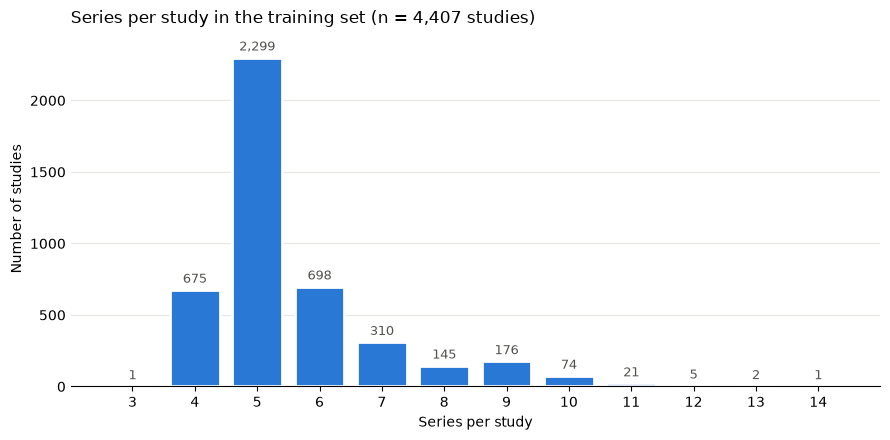

count    4407.00
mean        5.53
std         1.39
min         3.00
25%         5.00
50%         5.00
75%         6.00
max        14.00

29 studies contain more than 10 series.


,n_series,Axial,Coronal,Sagittal
StudyInstanceUID,,,,
1.2.826.0.1.3680043.8.498.63564058504808107209753434989270686941,14,5,4,5
1.2.826.0.1.3680043.8.498.34753112960188810416088070814158959510,13,6,3,4
1.2.826.0.1.3680043.8.498.24940437326555494150792221007907527983,13,5,3,5
1.2.826.0.1.3680043.8.498.31220970065722563280311764269386457090,12,7,3,2
1.2.826.0.1.3680043.8.498.24758830794084473905762034032291806038,12,2,4,6
1.2.826.0.1.3680043.8.498.12980448935316870673341494036873313299,12,6,4,2
1.2.826.0.1.3680043.8.498.63510378689078892579575716369639643386,12,6,3,3
1.2.826.0.1.3680043.8.498.11302750434639976191333636496428935632,12,4,4,4
1.2.826.0.1.3680043.8.498.12638205949145637289277744267473965719,11,3,4,4


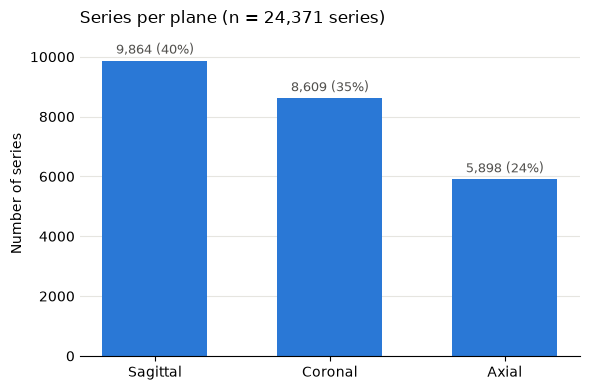

Sagittal: 9,864 series, missing from 0 studies
Coronal: 8,609 series, missing from 0 studies
Axial: 5,898 series, missing from 0 studies

Weighting source: DICOM header 23,165, description only 1,206, unknown 0 series
Note: Fat_Suppression and Fluid_Sensitive are identical for every series.


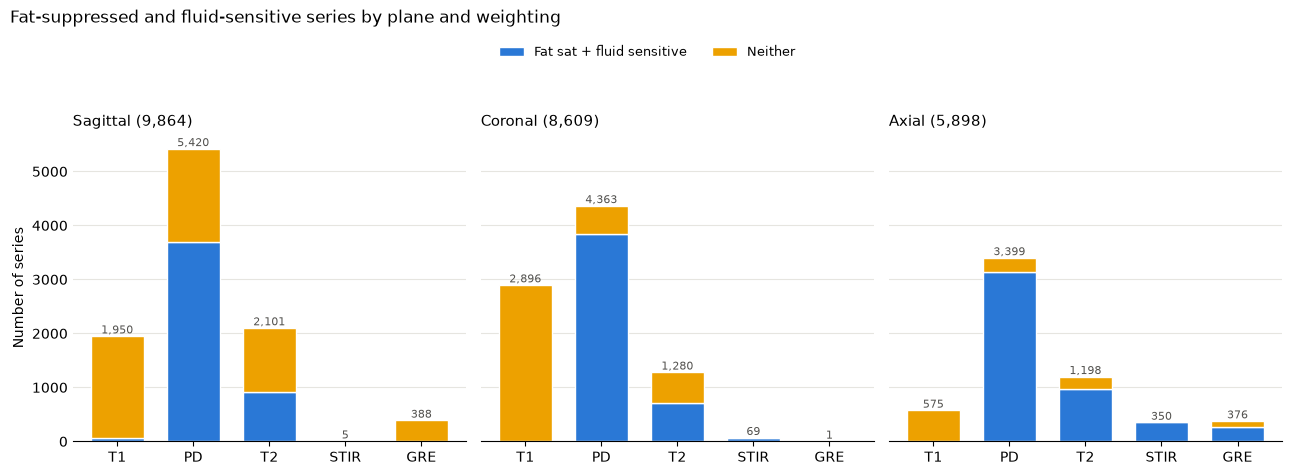

combo               Fat sat + fluid sensitive  Neither  Total  Fat sat %  \
Plane    Weighting                                                         
Sagittal T1                                63     1887   1950        3.2   
         PD                              3685     1735   5420       68.0   
         T2                               914     1187   2101       43.5   
         STIR                               5        0      5      100.0   
         GRE                                0      388    388        0.0   
Coronal  T1                                 0     2896   2896        0.0   
         PD                              3839      524   4363       88.0   
         T2                               715      565   1280       55.9   
         STIR                              69        0     69      100.0   
         GRE                                1        0      1      100.0   
Axial    T1                                 2      573    575        0.3   
         PD                              3130      269   3399       92.1   
         T2                               968      230   1198       80.8   
         STIR                             350        0    350      100.0   
         GRE                              269      107    376       71.5   

combo               Fluid sensitive %  
Plane    Weighting                     
Sagittal T1                       3.2  
         PD                      68.0  
         T2                      43.5  
         STIR                   100.0  
         GRE                      0.0  
Coronal  T1                       0.0  
         PD                      88.0  
         T2                      55.9  
         STIR                   100.0  
         GRE                    100.0  
Axial    T1                       0.3  
         PD                      92.1  
         T2                      80.8  
         STIR                   100.0  
         GRE                     71.5

In [1]:
# 05 — Training dataset statistics
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_ROOT = Path("F:/Kaggle/data")
TRAIN_CSV = DATA_ROOT / "train.csv"
TRAIN_SERIES_CSV = DATA_ROOT / "train_series.csv"
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MANIFEST_CSV = REPO_ROOT / "work/manifest/manifest.csv"  # DICOM header data (TE/TR/TI), output of build-manifest

BAR_COLOR = "#2a78d6"
INK_MUTED = "#52514e"
GRID_COLOR = "#e6e5e0"


def style_axes(ax):
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.tick_params(axis="y", length=0)


def fmt_int(v):
    return f"{v:,}"


train = pd.read_csv(TRAIN_CSV, dtype={"StudyInstanceUID": str})
series = pd.read_csv(TRAIN_SERIES_CSV, dtype={"StudyInstanceUID": str, "SeriesInstanceUID": str})

# 1. How many series does each study contain?
series_per_study = (
    series.groupby("StudyInstanceUID")["SeriesInstanceUID"].nunique()
    .reindex(train["StudyInstanceUID"], fill_value=0)  # keep studies without any series visible
)
dist = series_per_study.value_counts().sort_index()
dist = dist.reindex(range(dist.index.min(), dist.index.max() + 1), fill_value=0)

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(dist.index, dist.values, width=0.8, color=BAR_COLOR, edgecolor="white", linewidth=2, zorder=2)
ax.bar_label(bars, labels=[fmt_int(v) if v else "" for v in dist.values], padding=3, fontsize=9, color=INK_MUTED)
ax.set_xticks(dist.index)
ax.set_xlabel("Series per study")
ax.set_ylabel("Number of studies")
ax.set_title(f"Series per study in the training set (n = {fmt_int(len(series_per_study))} studies)",
             loc="left", fontsize=12)
style_axes(ax)
ax.margins(y=0.08)
plt.tight_layout()
plt.show()

print(series_per_study.describe().round(2).to_string())

# 2. Studies with more than 10 series
MANY_SERIES_THRESHOLD = 10

many_series = series_per_study[series_per_study > MANY_SERIES_THRESHOLD]
plane_counts = (
    series[series["StudyInstanceUID"].isin(many_series.index)]
    .pivot_table(index="StudyInstanceUID", columns="Anatomical_Plane",
                 values="SeriesInstanceUID", aggfunc="nunique", fill_value=0)
)
many_series_table = (
    many_series.rename("n_series").to_frame()
    .join(plane_counts)
    .sort_values("n_series", ascending=False)
)

print(f"\n{len(many_series_table)} studies contain more than {MANY_SERIES_THRESHOLD} series.")
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(many_series_table)

# 3. Number of series per anatomical plane
PLANE_ORDER = ["Sagittal", "Coronal", "Axial"]
plane_totals = series["Anatomical_Plane"].value_counts().reindex(PLANE_ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(plane_totals.index, plane_totals.values, width=0.6, color=BAR_COLOR, zorder=2)
ax.bar_label(bars, labels=[f"{fmt_int(v)} ({v / plane_totals.sum():.0%})" for v in plane_totals.values],
             padding=3, fontsize=9, color=INK_MUTED)
ax.set_ylabel("Number of series")
ax.set_title(f"Series per plane (n = {fmt_int(plane_totals.sum())} series)", loc="left", fontsize=12)
style_axes(ax)
ax.margins(y=0.1)
plt.tight_layout()
plt.show()

planes_per_study = series.groupby("StudyInstanceUID")["Anatomical_Plane"].agg(set).reindex(train["StudyInstanceUID"])
for plane in PLANE_ORDER:
    missing = planes_per_study.map(lambda s: not isinstance(s, set) or plane not in s).sum()
    print(f"{plane}: {fmt_int(plane_totals[plane])} series, missing from {missing} studies")

# 4. Fat suppression and fluid sensitivity by plane and sequence weighting (T1 / PD / T2 / ...)
# The weighting is not in train_series.csv: it is derived from the DICOM TE/TR/TI values,
# falling back to series description keywords only when those are missing.
#   GRE = gradient echo (ScanningSequence GR),  STIR = inversion recovery with TI of 100-300 ms,
#   T1  = TR < 1000 ms,  PD = TR >= 1000 ms and TE < 50 ms,  T2 = TR >= 1000 ms and TE >= 50 ms.
WEIGHTING_ORDER = ["T1", "PD", "T2", "STIR", "GRE", "Unknown"]
if not MANIFEST_CSV.is_file():
    raise FileNotFoundError(f"Not found: {MANIFEST_CSV}. Build the manifest first.")
manifest = pd.read_csv(MANIFEST_CSV, dtype={"SeriesInstanceUID": str}, low_memory=False)
manifest = manifest.drop_duplicates("SeriesInstanceUID").set_index("SeriesInstanceUID")

seq = manifest["scanning_sequence"].fillna("").astype(str)
te, tr = manifest["echo_time"], manifest["repetition_time"]
ti = manifest["inversion_time"].fillna(0)
desc = manifest["series_description"].fillna("").str.lower()
has_times = te.notna() & tr.notna()
from_header = [seq.str.contains("GR"), seq.str.contains("IR") & ti.between(100, 300),
               has_times & (tr < 1000), has_times & (te < 50), has_times]
from_desc = [desc.str.contains("stir"), desc.str.contains("t1"), desc.str.contains(r"pd|dp"), desc.str.contains("t2")]
manifest["weighting"] = np.select(from_header + from_desc,
                                  ["GRE", "STIR", "T1", "PD", "T2", "STIR", "T1", "PD", "T2"],
                                  default="Unknown")
desc_only = ~np.logical_or.reduce(from_header) & (manifest["weighting"] != "Unknown")

seq_stats = series.assign(weighting=series["SeriesInstanceUID"].map(manifest["weighting"]).fillna("Unknown"))
print(f"\nWeighting source: DICOM header {fmt_int(int(np.logical_or.reduce(from_header).sum()))}, "
      f"description only {fmt_int(int(desc_only.sum()))}, "
      f"unknown {fmt_int(int((seq_stats['weighting'] == 'Unknown').sum()))} series")

COMBOS = {  # (Fat_Suppression, Fluid_Sensitive) -> label, color
    (1, 1): ("Fat sat + fluid sensitive", "#2a78d6"),
    (0, 1): ("Fluid sensitive, no fat sat", "#eb6834"),
    (1, 0): ("Fat sat, not fluid sensitive", "#1baf7a"),
    (0, 0): ("Neither", "#eda100"),
}
flag_pairs = list(zip(seq_stats["Fat_Suppression"].astype(int), seq_stats["Fluid_Sensitive"].astype(int)))
seq_stats["combo"] = [COMBOS[pair][0] for pair in flag_pairs]
COMBOS = {pair: COMBOS[pair] for pair in COMBOS if pair in set(flag_pairs)}  # only the combinations that occur
combo_labels = [label for label, _ in COMBOS.values()]
if (seq_stats["Fat_Suppression"] == seq_stats["Fluid_Sensitive"]).all():
    print("Note: Fat_Suppression and Fluid_Sensitive are identical for every series.")
weightings = [w for w in WEIGHTING_ORDER if w in set(seq_stats["weighting"])]

combo_table = (
    pd.crosstab([seq_stats["Anatomical_Plane"], seq_stats["weighting"]], seq_stats["combo"])
    .reindex(columns=combo_labels, fill_value=0)
    .reindex(pd.MultiIndex.from_product([PLANE_ORDER, weightings], names=["Plane", "Weighting"]), fill_value=0)
)

fig, axes = plt.subplots(1, len(PLANE_ORDER), figsize=(13, 4.8), sharey=True)
for ax, plane in zip(axes, PLANE_ORDER):
    counts = combo_table.loc[plane]
    bottom = np.zeros(len(counts))
    for label, color in COMBOS.values():
        ax.bar(counts.index, counts[label], bottom=bottom, width=0.7, color=color,
               edgecolor="white", linewidth=1, zorder=2, label=label)
        bottom += counts[label].to_numpy()
    for x, total in enumerate(bottom):
        if total:
            ax.text(x, total, fmt_int(int(total)), ha="center", va="bottom", fontsize=8, color=INK_MUTED)
    ax.set_title(f"{plane} ({fmt_int(int(bottom.sum()))})", loc="left", fontsize=11)
    style_axes(ax)
axes[0].set_ylabel("Number of series")
fig.legend(combo_labels, loc="upper center", ncol=len(combo_labels), frameon=False, fontsize=9,
           bbox_to_anchor=(0.5, 0.93))
fig.suptitle("Fat-suppressed and fluid-sensitive series by plane and weighting",
             x=0.01, ha="left", fontsize=12)
plt.tight_layout(rect=(0, 0, 1, 0.86))
plt.show()

combo_table_display = combo_table.assign(
    Total=combo_table.sum(axis=1),
    **{"Fat sat %": (seq_stats.groupby(["Anatomical_Plane", "weighting"])["Fat_Suppression"].mean() * 100)
       .reindex(combo_table.index).round(1),
       "Fluid sensitive %": (seq_stats.groupby(["Anatomical_Plane", "weighting"])["Fluid_Sensitive"].mean() * 100)
       .reindex(combo_table.index).round(1)},
)
with pd.option_context("display.max_rows", None):
    display(combo_table_display[combo_table_display["Total"] > 0])